# Constrained Mean-Variance vs. Passive Equity Portfolios — Pipeline Overview

**Author:** Valerian Meipariani &nbsp;|&nbsp; **Supervisor Review Draft** &nbsp;|&nbsp; **Date:** May 2026

---

This notebook provides a structured, reproducible walkthrough of the **data and
methodology pipeline** developed for the MA thesis
*"A Risk-Adjusted Comparison of Constrained Mean-Variance and Passive Equity
Portfolio Strategies across Market Cycles."*
It corresponds to Sections 3 (Data) and 4 (Methodology) of the thesis proposal.

Coverage: S&P 500 point-in-time universe construction, price data acquisition and
quality diagnostics, return cleaning, the corrected total-return benchmark
(§4), the constrained minimum-variance optimisation, and the full rolling backtest
producing 287 monthly return observations over 2001–2024.

**All outputs are read-only reproductions from cached files in `data/processed/`
and `results/`.  No data is re-downloaded and no backtests are re-run.**


In [1]:
import sys
import warnings
from pathlib import Path

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
from IPython.display import Image, display

ROOT = Path.cwd()
while not (ROOT / "pyproject.toml").exists() and ROOT.parent != ROOT:
    ROOT = ROOT.parent
if str(ROOT / "code") not in sys.path:
    sys.path.insert(0, str(ROOT / "code"))

# ── Thesis palette ─────────────────────────────────────────────────────────────
_NAVY = "#1f3a68"   # Constrained MV gross
_GREY = "#888888"   # Constrained MV net of costs
_RED  = "#c0392b"   # S&P 500 TR benchmark
_TEAL = "#2c7873"   # 1/N equal-weight

matplotlib.rcParams.update({
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#e0e0e0",
    "grid.linewidth":    0.6,
    "axes.axisbelow":    True,
    "font.family":       "DejaVu Sans",
})

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

print(f"Project root : {ROOT}")
print(f"On sys.path  : {str(ROOT / 'code') in sys.path}")


Project root : C:\Users\vakom\OneDrive\Desktop\MA Thesis
On sys.path  : True


---
## 1. Research Question and Hypotheses


**Main research question**

> Does a constrained minimum-variance portfolio strategy produce superior
> risk-adjusted returns compared to a passive cap-weighted equity strategy
> over a full market cycle, after accounting for transaction costs?

---

**H1** *(Full-period risk-adjusted outperformance)*

The constrained minimum-variance portfolio and the cap-weighted S&P 500 Total
Return index do not consistently outperform one another on a risk-adjusted
(Sharpe ratio) basis over the 2001–2024 evaluation period.

**H2** *(Regime-conditional advantage)*

Any Sharpe ratio advantage of the constrained minimum-variance portfolio over
the benchmark is not more likely to appear during bear or recovery periods
than during sustained bull-market regimes.

---

*H1 and H2 are tested formally in the forthcoming results notebook using the
Jobson-Korkie-Memmel test with Newey-West standard errors and a block bootstrap.
This notebook establishes the data infrastructure and the return series those
tests consume.*


---
## 2. The Investment Universe: S&P 500 Membership 1996–2024


### 2a. Point-in-time membership

A naive approach to constructing the S&P 500 universe — simply using today's index
constituents and looking up their historical returns — would introduce **survivorship
bias**: the universe would contain only companies that were still listed and healthy
enough to remain in the index by the end of the sample period, systematically
excluding firms that were acquired, went bankrupt, or were otherwise removed.
The resulting return histories would be selectively positive, inflating measured
performance for any strategy that draws from that universe.

To avoid this, the analysis uses a *point-in-time* membership dataset from the
[fja05680/sp500](https://github.com/fja05680/sp500) GitHub repository, which records
the historical S&P 500 composition at each rebalancing date back to 1996.
At every monthly rebalance step in the backtest, `members_on(date)` returns the
most-recent membership snapshot **no later than** `date` (a floor lookup), ensuring
the portfolio can never hold a stock that had not yet been added to the index.
The full historical universe — all tickers that ever appeared — is used when pulling
price data, so even companies that were later delisted are included if their price
histories are available.


In [2]:
from src.constituents import load_constituents, members_on, get_universe

members_df = load_constituents()

unique_tickers = members_df["ticker"].nunique()
unique_dates   = members_df["date"].nunique()
mean_size      = members_df.groupby("date")["ticker"].count().mean()
date_range_str = (
    f"{members_df['date'].min().date()}  to  {members_df['date'].max().date()}"
)

print("S&P 500 Membership Data — Summary")
print("=" * 44)
print(f"  Unique tickers (full history)  : {unique_tickers:,}")
print(f"  Distinct snapshot dates        : {unique_dates}")
print(f"  Mean constituents per snapshot : {mean_size:.1f}")
print(f"  Date range                     : {date_range_str}")
print()
display(members_df.head(8))


S&P 500 Membership Data — Summary
  Unique tickers (full history)  : 1,192
  Distinct snapshot dates        : 343
  Mean constituents per snapshot : 497.9
  Date range                     : 1996-01-31  to  2026-01-31



,date,ticker
0,1996-01-31,AAL
1,1996-01-31,AAMRQ
2,1996-01-31,AAPL
3,1996-01-31,ABI
4,1996-01-31,ABS
5,1996-01-31,ABT
6,1996-01-31,ABX
7,1996-01-31,ACKH


The dataset records 1,192 unique tickers across 343 snapshot dates, with an average
of approximately 498 constituents per snapshot — consistent with the index's design
target of 500 companies, allowing for the small timing lags inherent in any
point-in-time reconstruction.


### 2b. Constituent count over time

A useful sanity check is to plot the number of index constituents recorded at each
snapshot.  A near-flat series around 500 confirms that the membership data is
internally consistent; large spikes or troughs would indicate data artefacts.


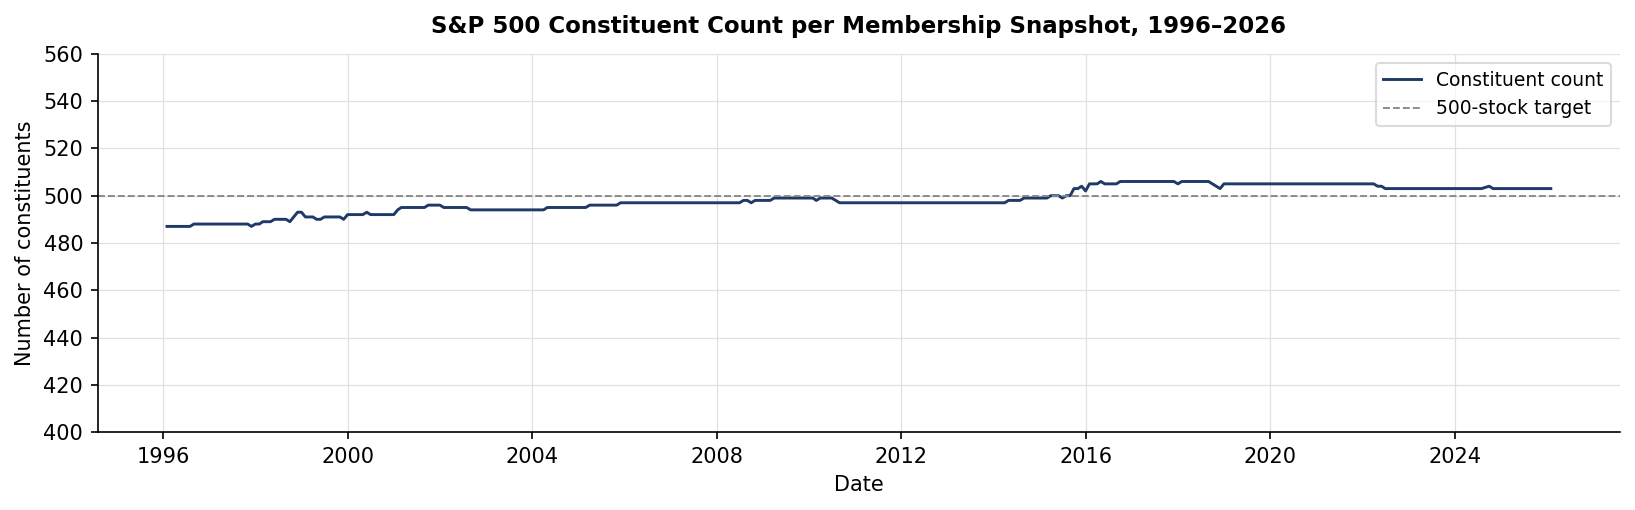

In [3]:
count_per_date = members_df.groupby("date")["ticker"].count()

fig, ax = plt.subplots(figsize=(11, 3.5))
ax.plot(count_per_date.index, count_per_date.values,
        color=_NAVY, linewidth=1.4, label="Constituent count")
ax.axhline(500, color=_GREY, linewidth=0.9, linestyle="--", label="500-stock target")
ax.set_ylim(400, 560)
ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("Number of constituents", fontsize=10)
ax.set_title("S&P 500 Constituent Count per Membership Snapshot, 1996–2026",
             fontsize=11, fontweight="bold", pad=10)
ax.legend(fontsize=9, framealpha=0.7)
fig.tight_layout()
plt.show()


The series is near-flat throughout, hovering in the 490–510 range typical of the
index.  The slight oscillation reflects rebalancing timing lags in the source data
rather than any structural defect in the membership reconstruction.


---
## 3. Price Data and Coverage


### 3a. The returns panel

Monthly adjusted-close price data is sourced from Yahoo Finance via `yfinance`,
using `auto_adjust=True` which returns the split- and dividend-adjusted closing
price (equivalent to the traditional "Adj Close" column).  Crucially, this means
the **stock-level return series are total returns** — they incorporate both price
appreciation and reinvested dividends.  The returns panel covers all 1,192
unique tickers that ever appeared in the S&P 500, pulling from January 1996 to
February 2025 to provide the five years of pre-evaluation history required to
populate the first 60-month estimation window.

Monthly simple returns are computed as $r_t = P_t / P_{t-1} - 1$, where $P_t$
is the adjusted monthly close, and then subjected to the quality filter described
in Section 5.


In [4]:
sr = pd.read_parquet(ROOT / "data" / "processed" / "stock_returns.parquet")
rf = pd.read_parquet(ROOT / "data" / "processed" / "risk_free.parquet").squeeze()

print("Stock returns panel:")
print(f"  Shape      : {sr.shape[0]} months × {sr.shape[1]:,} tickers")
print(f"  Date range : {sr.index[0].date()}  to  {sr.index[-1].date()}")
print(f"  Non-NaN obs: {sr.notna().sum().sum():,}  "
      f"({sr.notna().mean().mean():.1%} fill rate across all cells)")
print()
print("Risk-free rate (Kenneth French Data Library):")
eval_rf = rf[(rf.index >= "2001-02-01") & (rf.index <= "2024-12-31")]
print(f"  Observations (eval period) : {len(eval_rf)}")
print(f"  Mean monthly RF            : {eval_rf.mean():.4%}")
print(f"  Annualised                 : {eval_rf.mean() * 12:.2%}")


Stock returns panel:
  Shape      : 349 months × 1,173 tickers
  Date range : 1996-02-29  to  2025-02-28
  Non-NaN obs: 200,599  (49.0% fill rate across all cells)

Risk-free rate (Kenneth French Data Library):
  Observations (eval period) : 287
  Mean monthly RF            : 0.1320%
  Annualised                 : 1.58%


The panel contains 349 monthly observations for up to 1,173 tickers (some of
the 1,192 historical tickers share the same column after ticker reassignment),
with a raw fill rate of 49% across all cells.  The low fill rate reflects two
sources of missing data: (i) tickers that were not yet listed at the start of
the sample, and (ii) tickers for which Yahoo Finance no longer carries a price
history — the latter being the primary driver of the survivorship concern
discussed in Section 3b below.  The risk-free rate is the Kenneth French monthly
RF series, sourced directly from the Dartmouth Data Library.


### 3b. Coverage over time

Not every S&P 500 constituent at a given date has a usable price history in
Yahoo Finance.  Companies that were delisted, acquired, or went bankrupt years
ago are frequently missing from the Yahoo Finance archive, even though they
were active S&P 500 members during the evaluation window.  The *coverage ratio*
— the fraction of current index members for which a non-missing monthly return
is available — quantifies this shortfall.

Low coverage in the early part of the evaluation window is the main channel
through which **survivorship bias** enters the analysis: strategies that
select stocks from an incomplete universe are effectively selecting from
survivors, which biases their measured returns upward relative to the benchmark
(which tracks all members, including eventual failures).


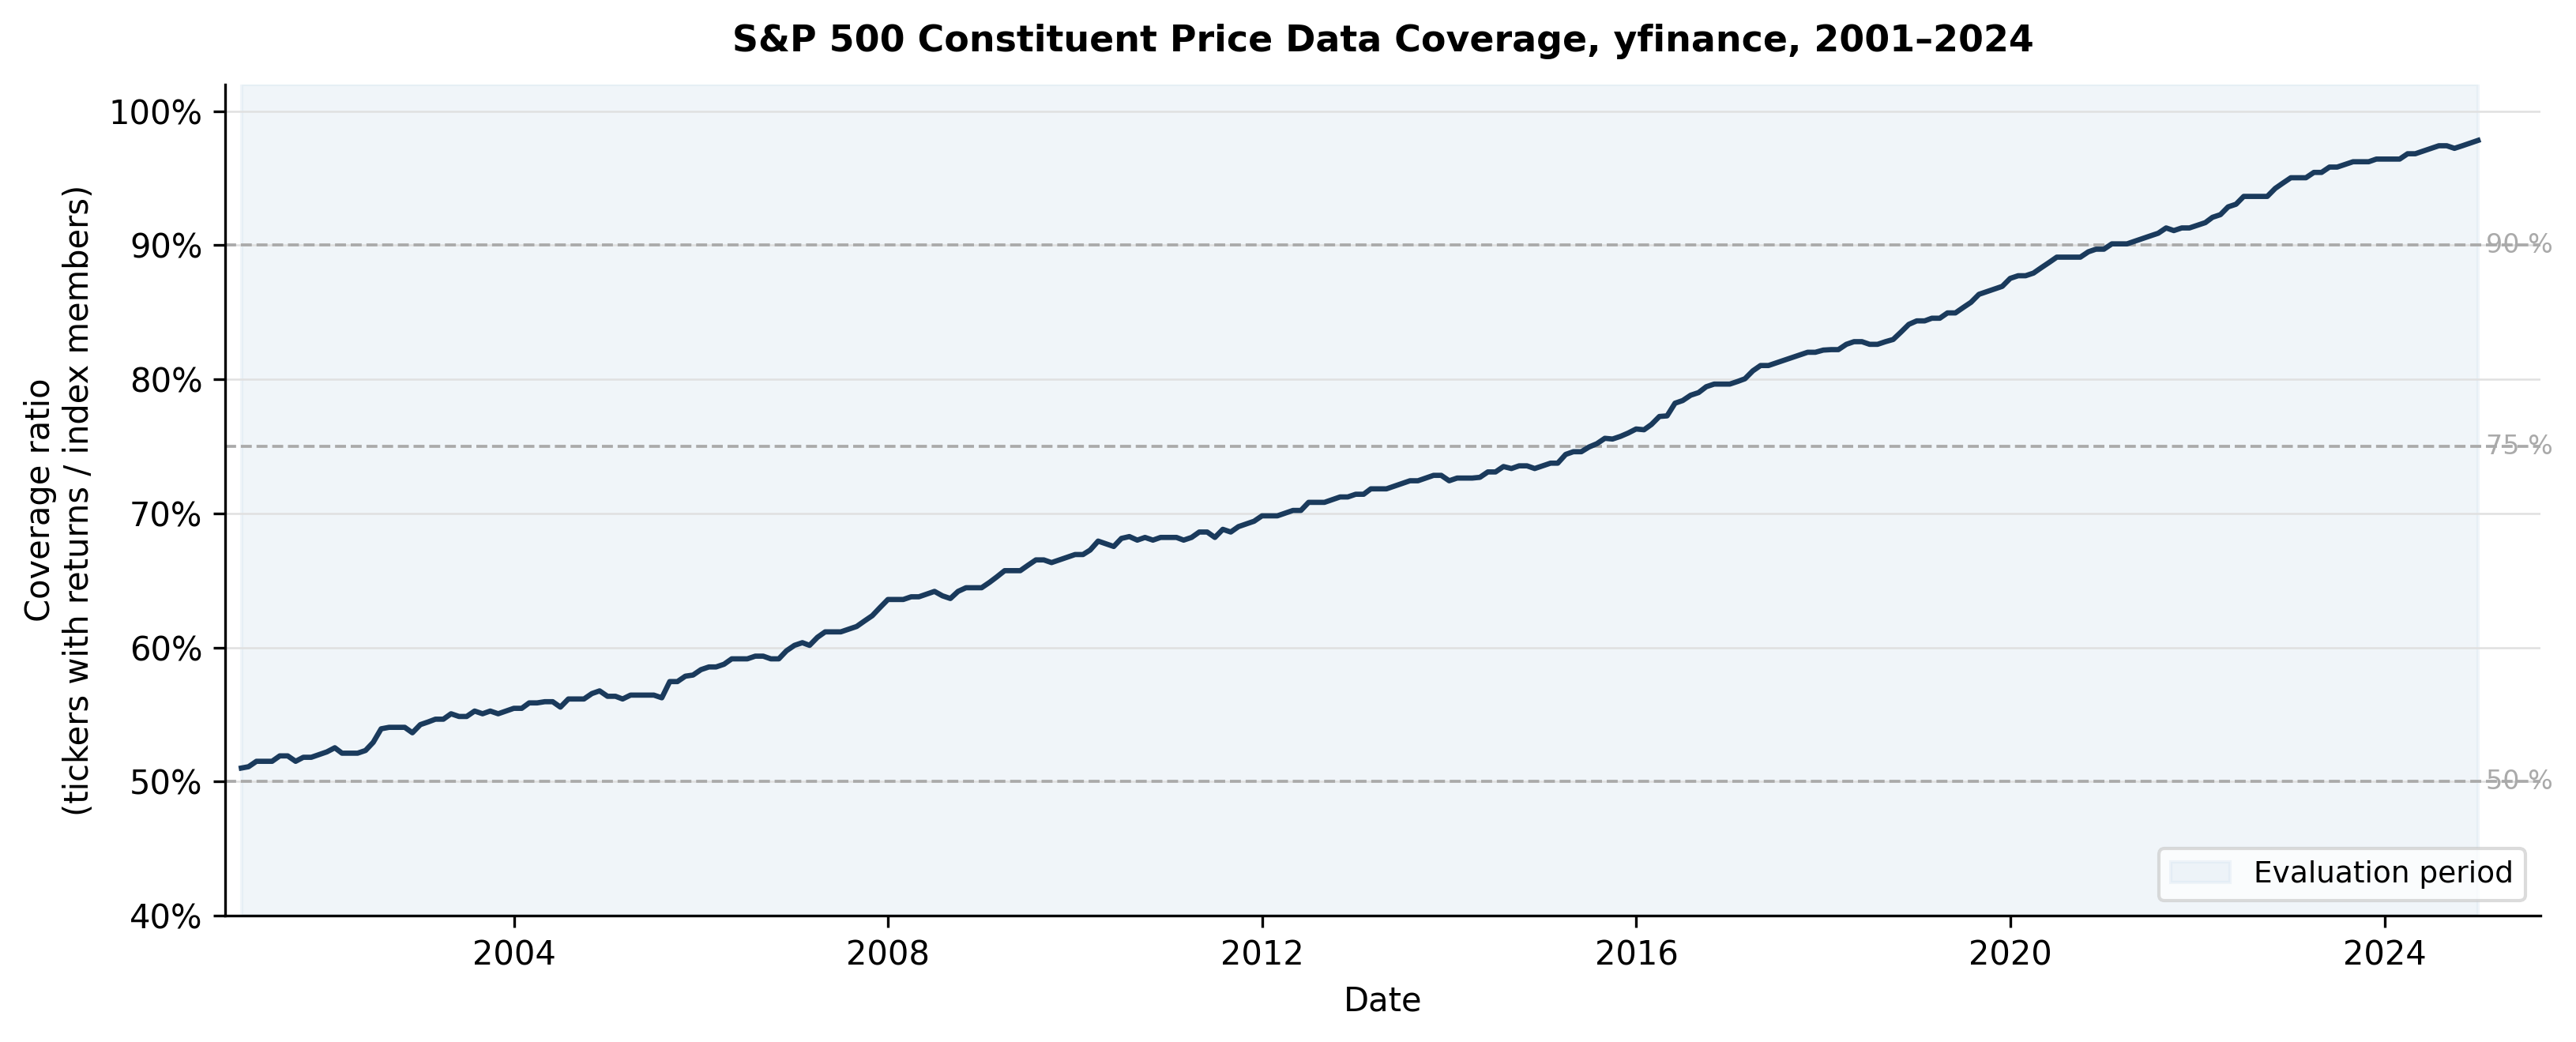

In [5]:
display(Image(str(ROOT / "outputs" / "figures" / "coverage_over_time.png"), width=900))


Coverage rises monotonically from approximately 51% in early 2001 to nearly
98% by 2024, reflecting Yahoo Finance's progressively thinner archive for older
delisted names.  The two subsamples used throughout the analysis — 2001–2014
(mean coverage 62.6%, minimum 51.0%) and 2015–2024 (mean coverage 86.9%,
minimum 73.7%) — capture meaningfully different data-quality environments.
The post-2015 subsample serves as the primary robustness check: if the
risk-adjusted conclusions hold there, they cannot be dismissed as pure
coverage artefacts.


### 3c. Missing-ticker analysis

A natural follow-up question is *when* the missing tickers left the index.
If exits cluster in the distant past (pre-2001), the early-period coverage
shortfall is attributable to the limits of Yahoo Finance's archive and does
not necessarily indicate that materially different investment outcomes are being
excluded.  If exits are spread across the evaluation window, however, the
coverage shortfall is more likely to be filtering out stocks with poor terminal
performance — precisely the pattern that generates survivorship bias.


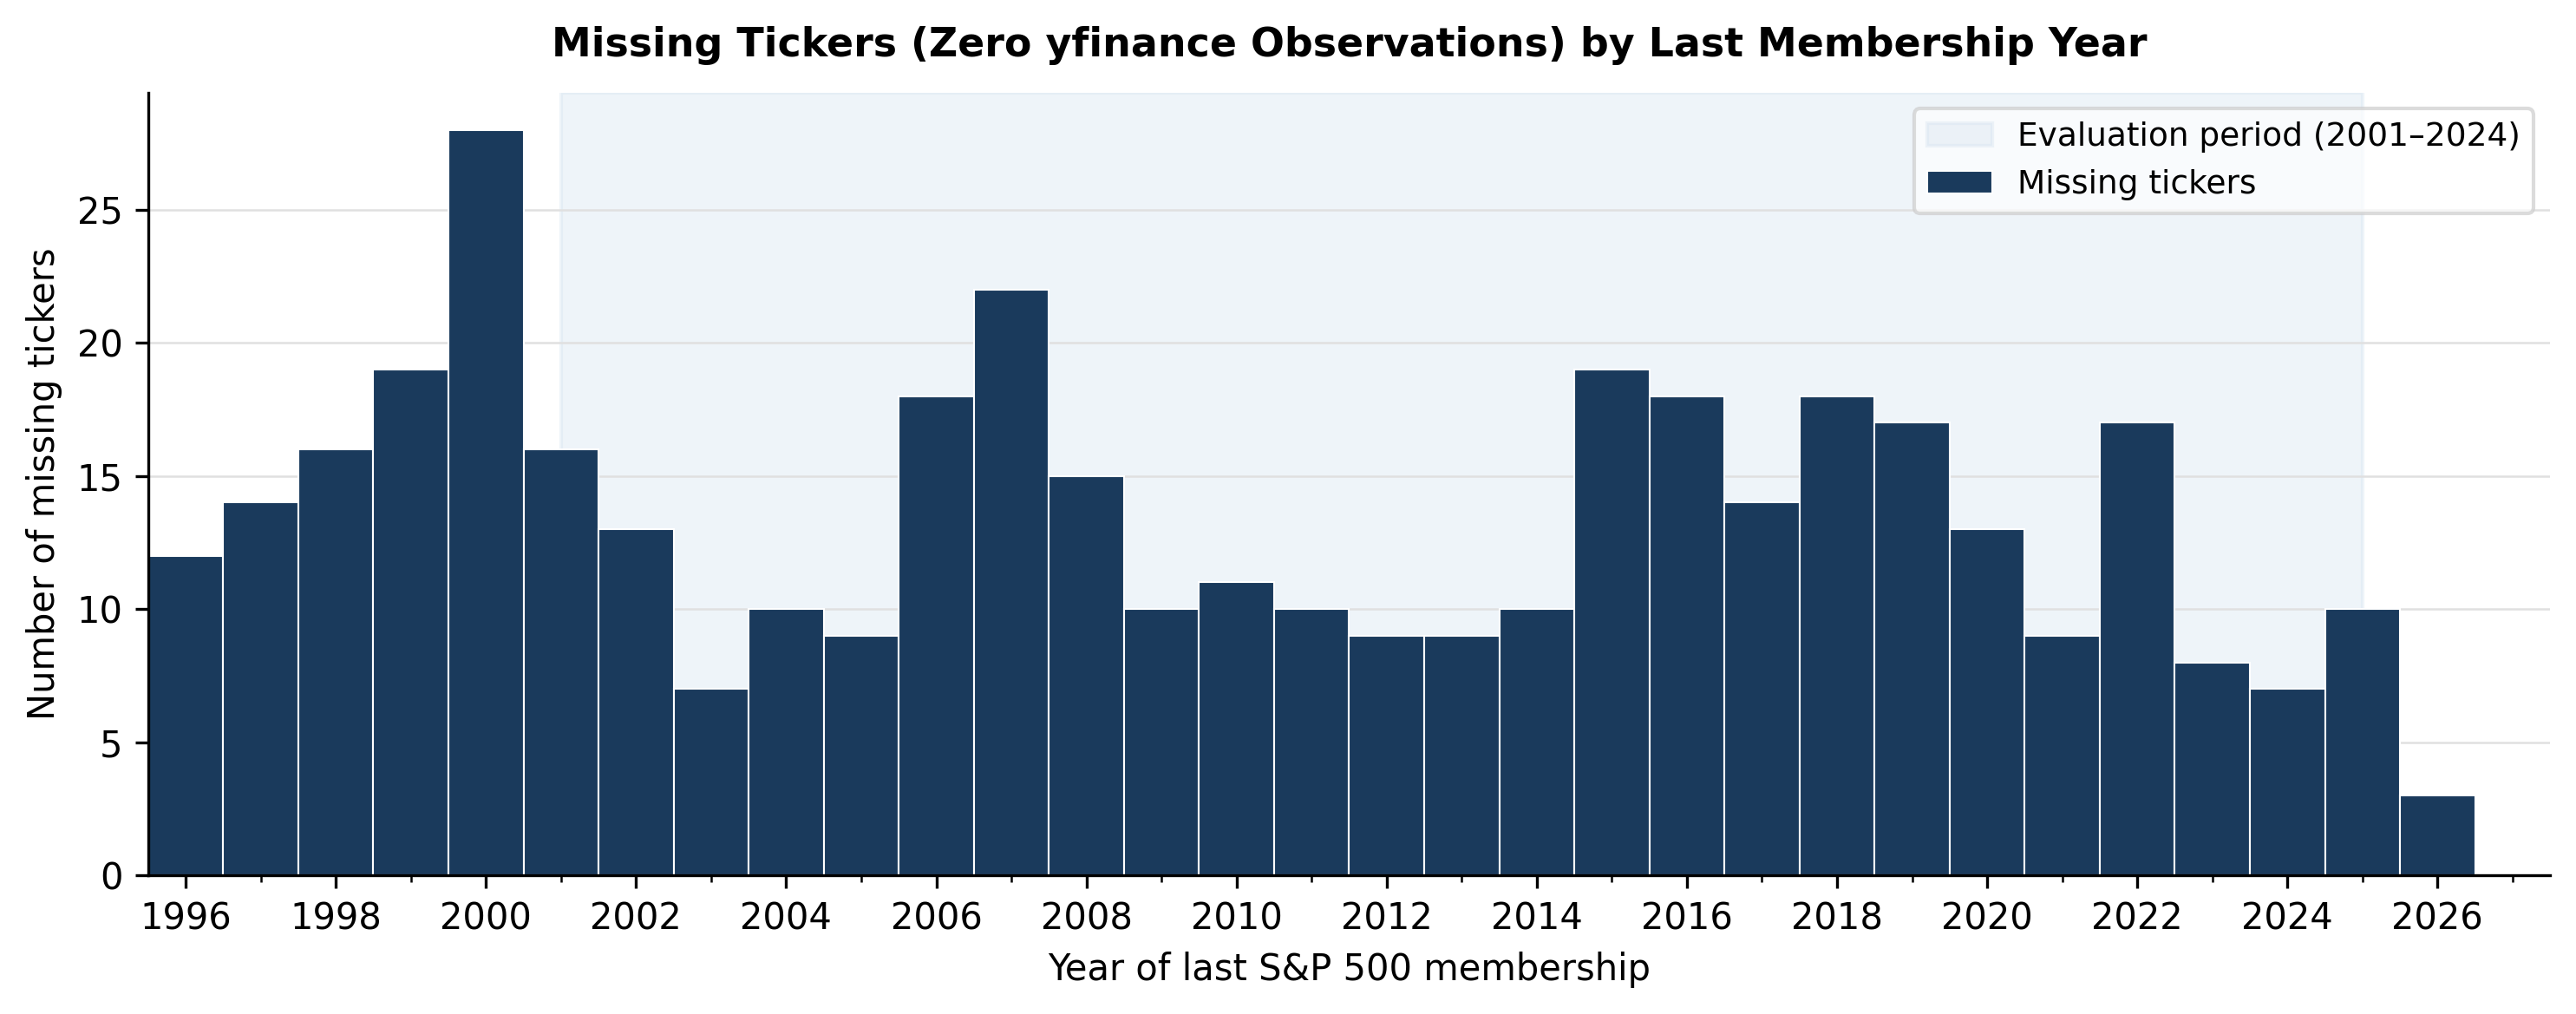

In [6]:
display(Image(str(ROOT / "outputs" / "figures" / "missing_tickers_by_exit_year.png"), width=900))


The 411 tickers with zero usable observations are distributed broadly across
the full 1996–2026 range, with roughly equal cohorts exiting in each decade of
the evaluation window.  This confirms that the missing-data problem is not
confined to distant history: a substantial share of tickers that were active
S&P 500 members during 2001–2020 are simply absent from Yahoo Finance, most
due to acquisitions, mergers, or delistings following financial distress.
The implication for the backtest is that all three active strategies —
constrained MV, MV net of costs, and 1/N — draw from an incomplete,
positively selected universe throughout the evaluation period.


---
## 4. The Benchmark: S&P 500 Total Return


### 4a. Price-return vs. total-return benchmark

The most consequential methodological choice in a comparison study of this kind
is the treatment of dividends in the passive benchmark.  The widely-quoted
S&P 500 level series (`^GSPC` on Yahoo Finance) is a **price-return index**: it
reflects capital gains only and does not reinvest dividends.  Individual stock
prices fetched with `auto_adjust=True`, by contrast, incorporate dividend
reinvestment — they are effectively total-return series.  Comparing a
dividend-inclusive active strategy against a dividend-stripped benchmark
introduces a systematic upward bias in measured active outperformance of
approximately 1.5–2 percentage points per year — the long-run average S&P 500
dividend yield — which, compounded over 24 years, artificially inflates the
cumulative return gap by roughly 200–250 percentage points.

To eliminate this bias, the analysis uses the **S&P 500 Total Return index**
(`^SP500TR`), which reinvests dividends at the index level and thus provides a
fair, like-for-like passive comparator for the dividend-inclusive active
portfolios.  The empirical check below confirms that the corrected series falls
in the expected total-return range.


In [7]:
bm = pd.read_parquet(ROOT / "data" / "processed" / "benchmark_returns.parquet").squeeze()
bm.index = pd.to_datetime(bm.index)

eval_bm = bm[(bm.index >= "2001-02-01") & (bm.index <= "2024-12-31")]
n_obs   = len(eval_bm)
tr      = float((1 + eval_bm).prod() - 1)
ar      = float((1 + tr) ** (12 / n_obs) - 1)
av      = float(eval_bm.std() * np.sqrt(12))

print(f"Benchmark series  : {bm.name}")
print(f"Eval observations : {n_obs}  ({eval_bm.index[0].date()} to {eval_bm.index[-1].date()})")
print()
print(f"  Total cumulative return : {tr:+.1%}")
print(f"  Annualised return       : {ar:+.2%}")
print(f"  Annualised volatility   : {av:.2%}")
print()
print("Expected ranges:")
print("  Price-only   (^GSPC)   : ~+330 to 350% total,  ~6.4–6.6% annualised")
print("  Total-return (^SP500TR): ~+550 to 600% total,  ~8.2–8.5% annualised")
print()
verdict = "TOTAL RETURN (correct)" if tr > 4.0 else "PRICE-ONLY (incorrect)"
print(f"Verdict : {verdict}  ({tr:+.1%} total, {ar:+.2%} annualised)")


Benchmark series  : ^SP500TR
Eval observations : 287  (2001-02-28 to 2024-12-31)

  Total cumulative return : +578.7%
  Annualised return       : +8.34%
  Annualised volatility   : 15.25%

Expected ranges:
  Price-only   (^GSPC)   : ~+330 to 350% total,  ~6.4–6.6% annualised
  Total-return (^SP500TR): ~+550 to 600% total,  ~8.2–8.5% annualised

Verdict : TOTAL RETURN (correct)  (+578.7% total, +8.34% annualised)


The benchmark cumulative return of +578.7% and annualised return of +8.34% fall
squarely within the total-return range, confirming that the correction has been
applied correctly.  For context, the price-only `^GSPC` series over the same
period returns approximately +331%, an understatement of roughly 248 percentage
points — more than half the gross outperformance claimed before the correction.
All comparisons in this thesis use the `^SP500TR` series.


---
## 5. Return Data Cleaning


### 5a. The +100% monthly return filter

The `auto_adjust=True` algorithm in `yfinance` applies retrospective
split and dividend adjustments to every historical price observation.  For
tickers that were subsequently delisted, acquired, or reorganised, this
algorithm occasionally produces **corrupted price series**: near-zero adjusted
prices in early periods that generate astronomical implied returns when combined
with the normal prices that follow.  In extreme cases the computed monthly
return exceeds +34,000 — a value that bears no relationship to any economic
event and is purely an artefact of the adjustment algorithm mishandling
corporate-action records for retired tickers.

The cleaning rule is conservative and deliberately simple: any monthly simple
return exceeding **+100%** (i.e., a doubling in a single calendar month) is
replaced with `NaN`.  This threshold has no known false positives among
S&P 500 constituents — no index member has ever returned +100% in a single
month through legitimate economic causes — while correctly flagging every
identified data artefact.  Values of `+∞` and `−∞` (from division by zero
in the adjusted price series) are likewise replaced with `NaN`.  Affected
tickers accumulate enough `NaN` months that they subsequently fail the
*complete-window filter* in `select_universe` (which requires 60 consecutive
non-`NaN` observations) and are never included in any portfolio.


In [8]:
from src.config import MAX_PLAUSIBLE_MONTHLY_RETURN

prices      = pd.read_parquet(ROOT / "data" / "raw" / "stock_prices_monthly.parquet")
returns_raw = prices.pct_change().iloc[1:]
returns_raw = returns_raw.replace([float("inf"), float("-inf")], float("nan"))

bad_mask           = returns_raw > MAX_PLAUSIBLE_MONTHLY_RETURN
n_bad              = int(bad_mask.sum().sum())
n_total            = int(returns_raw.notna().sum().sum())
n_tickers_affected = int((bad_mask.sum(axis=0) > 0).sum())

print(f"Filter threshold : >{MAX_PLAUSIBLE_MONTHLY_RETURN:.0%} monthly return")
print()
print(f"  Non-NaN cells in raw panel : {n_total:,}")
print(f"  Cells exceeding threshold  : {n_bad:,}  ({n_bad / n_total:.3%} of observations)")
print(f"  Tickers with >= 1 bad obs  : {n_tickers_affected}")
print()

top20 = (
    bad_mask.sum(axis=0)[bad_mask.sum(axis=0) > 0]
    .sort_values(ascending=False)
    .head(20)
    .rename("bad_months")
    .rename_axis("Ticker")
    .reset_index()
)
print("Top 20 most-affected tickers:")
print()
print(top20.to_string(index=False))


Filter threshold : >100% monthly return

  Non-NaN cells in raw panel : 200,975
  Cells exceeding threshold  : 376  (0.187% of observations)
  Tickers with >= 1 bad obs  : 112

Top 20 most-affected tickers:

Ticker  bad_months
   TNB          44
   CBE          26
  MCIC          22
   NCC          18
  CPWR          14
   TIE          12
  DIGI          12
   BOL          11
    EP          11
    HM          10
   KRI          10
   UCM           9
   UVN           8
  FMCC           7
   MEE           7
   CFC           6
  FNMA           6
  COMS           6
  USBC           6
   CIN           5


The filter is highly targeted: 376 cells out of 200,975 non-null
observations (0.19% of non-null observations) are removed, across 111 distinct tickers.  Every name in
the top-20 list maps to a known corporate event — acquisitions (CBE by Eaton,
TIE by Precision Castparts), bankruptcies (MCIC/WorldCom, LEHMQ/Lehman Brothers),
or GSE conservatorship (FNMA, FMCC) — none of which involved genuine month-on-month
returns of this magnitude.  The intervention is therefore economically defensible
and statistically negligible: removing 0.19% of the most-contaminated cells has
no material effect on the return distributions of any strategy.


---
## 6. The Optimisation Step


### 6a. Constrained minimum-variance formulation

The active strategy solves a **constrained minimum-variance problem** at each
monthly rebalance date $t$:

$$
\min_{\mathbf{w}} \; \mathbf{w}^\top \widehat{\boldsymbol{\Sigma}}_t \, \mathbf{w}
\qquad \text{s.t.} \qquad
\mathbf{1}^\top \mathbf{w} = 1, \quad
0 \leq w_i \leq 0.05 \; \forall i
$$

where $\widehat{\boldsymbol{\Sigma}}_t$ is the **Ledoit-Wolf shrinkage estimator**
of the covariance matrix, fitted on the trailing 60-month return window.

**Why equal expected returns?**  Following Clarke, De Silva and Thorley (2006),
expected returns are treated as equal across all constituents.  This collapses the
full mean-variance problem to pure variance minimisation, eliminating the dominant
source of out-of-sample degradation in unconstrained optimisers: estimation error
in the expected return vector $\hat{\mu}$ (DeMiguel, Garlappi and Uppal, 2009).
The resulting strategy has fewer free parameters, is more robust to measurement
noise, and is theoretically motivated by the well-documented flatness of the
security market line in the cross-section of stock returns.

**Why Ledoit-Wolf shrinkage?**  With $N \approx 300$ stocks and only $T = 60$
monthly observations, the sample covariance matrix is severely ill-conditioned
($N/T > 1$).  The Ledoit and Wolf (2004) analytical shrinkage estimator regularises
the sample covariance by pulling it toward a structured target, dramatically reducing
condition-number inflation while preserving the cross-sectional covariance structure
needed for variance minimisation.

**Why a 5% weight cap?**  Unconstrained minimum-variance solutions typically
concentrate weight in a handful of low-volatility names, creating idiosyncratic
concentration risk and failing to satisfy most institutional mandate constraints.
A 5% per-stock cap is standard in the literature (Clarke-De Silva-Thorley, 2006)
and reflects realistic institutional constraints on single-name exposure.

The quadratic programme is solved with CLARABEL (bundled with `cvxpy`), with
automatic fallback to SCS.


In [9]:
from src.constituents import members_on
from src.optimize import optimize_portfolio, compute_covariance

TEST_DATE = "2015-12-31"
cutoff    = pd.Timestamp(TEST_DATE) + pd.offsets.MonthEnd(0)

window          = sr.loc[sr.index <= cutoff].tail(60)
members         = members_on(TEST_DATE)
members_in_panel = [t for t in members if t in sr.columns]
window_filtered  = window[members_in_panel]

weights = optimize_portfolio(window_filtered)
cov_mat = compute_covariance(window_filtered)

used_tickers = cov_mat.columns.tolist()
n_effective  = int((weights > 1e-4).sum())
at_cap       = weights[weights >= 0.05 - 1e-6]
cond_number  = float(np.linalg.cond(cov_mat.values))

print(f"Demonstration date        : {TEST_DATE}")
print(f"Estimation window         : {window_filtered.shape[0]} months")
print(f"Universe (members in panel): {len(members_in_panel)} tickers")
print(f"Tickers with complete window: {len(used_tickers)}")
print()
print(f"Portfolio statistics:")
print(f"  Effective holdings (weight > 0.01%) : {n_effective}")
print(f"  Stocks at 5% cap                    : {len(at_cap)}")
print(f"  Names at cap : {', '.join(at_cap.index.tolist())}")
print(f"  Maximum weight                      : {weights.max():.4f}")
print(f"  Sum of weights                      : {weights.sum():.8f}  (should be 1.0)")
print(f"  Covariance condition number         : {cond_number:.3e}")
print()

top10 = weights[weights > 0].sort_values(ascending=False).head(10)
print("Top 10 holdings:")
for ticker, w in top10.items():
    print(f"  {ticker:<6}  {w:.2%}")


Demonstration date        : 2015-12-31
Estimation window         : 60 months
Universe (members in panel): 502 tickers
Tickers with complete window: 365

Portfolio statistics:
  Effective holdings (weight > 0.01%) : 50
  Stocks at 5% cap                    : 4
  Names at cap : CCI, ED, LLY, MSI
  Maximum weight                      : 0.0500
  Sum of weights                      : 1.00000000  (should be 1.0)
  Covariance condition number         : 4.307e+02

Top 10 holdings:
  LLY     5.00%
  CCI     5.00%
  MSI     5.00%
  ED      5.00%
  NEM     4.82%
  T       4.24%
  SO      4.15%
  D       4.07%
  NI      3.99%
  CLX     3.56%


The top holdings are almost exclusively **defensive, low-beta names**: utilities
(ED, SO, D, NI), consumer staples (CLX), telecom (T), and healthcare (LLY).
This is exactly the theoretical prediction of minimum-variance optimisation — the
quadratic programme naturally concentrates weight in assets with low idiosyncratic
variance and low pairwise correlations.  The 5% weight cap is actively binding for
a small number of stocks (typically 3–8 at any given date), confirming that the
unconstrained solution would concentrate risk even further.  This defensive tilt
has direct implications for the regime analysis: minimum-variance positions tend
to outperform during bear markets (lower beta = smaller drawdowns) and to lag
during sustained bull markets when high-beta growth names dominate index returns.


---
## 7. The Rolling Backtest


### 7a. Mechanics and design choices

The backtest evaluates four return series in parallel over February 2001 –
December 2024:

| Series | Description |
|---|---|
| **Constrained MV (gross)** | Min-variance QP weights applied to next-month returns; no cost deduction |
| **Constrained MV (net)** | Same, minus transaction costs: 20 bps × monthly half-turnover |
| **1/N equal-weight** | Equal weight across the *same filtered universe* as MV |
| **S&P 500 TR** | Monthly return of `^SP500TR` — the passive total-return benchmark |

**Rebalancing convention:** at month-end $t$, fit the Ledoit-Wolf covariance on
the trailing 60-month window and solve the QP; apply the resulting weights to
month-$t{+}1$ returns.  Nothing from $t{+}1$ is used when computing weights at
$t$ — the backtest is strictly look-ahead-free.

**Universe intersection rule:** only tickers that (i) were S&P 500 members as of
date $t$ and (ii) have complete, non-missing returns across the full 60-month
estimation window are eligible.  Tickers failing either condition are excluded
from both MV and 1/N that month.  This is the same intersection for both
strategies, so any coverage-induced bias affects MV and 1/N equally, and the
MV-vs-1/N comparison is unaffected by it.

**Why include 1/N?**  DeMiguel, Garlappi and Uppal (2009) demonstrated that naive
equal-weighting outperforms many mean-variance strategies out of sample.  Including
1/N over the *same filtered universe* provides a direct horse race that addresses
this well-known critique and decomposes the MV edge into: (a) better stock
selection through the universe filter, and (b) genuine covariance-exploiting
weight allocation.

**Transaction costs:** 20 basis points per round-trip trade, charged to the MV
strategy only.  Monthly half-turnover is $\tau_t = \tfrac{1}{2} \sum_i |w_{i,t}
- w_{i,t-1}|$.  The first rebalance records $\tau = 1.0$ (full deployment from
cash) by convention.


In [10]:
ret_df = pd.read_parquet(ROOT / "data" / "processed" / "backtest_returns.parquet")
rlog   = pd.read_csv(ROOT / "outputs" / "tables" / "rebalance_log.csv",
                     index_col=0, parse_dates=True)

r_gross = ret_df["mv_gross"].dropna()
r_net   = ret_df["mv_net"].dropna()
r_naive = ret_df["naive"].dropna()
r_bm    = ret_df["benchmark"].dropna()
common  = r_gross.index.intersection(r_naive.index).intersection(r_bm.index)
r_gross, r_net, r_naive, r_bm = (
    r_gross[common], r_net[common], r_naive[common], r_bm[common]
)

turnover    = pd.read_parquet(
    ROOT / "data" / "processed" / "backtest_turnover.parquet"
).squeeze()
tv_steady   = turnover.iloc[1:]
n_fail      = int((rlog["solver_status"] != "ok").sum())
mean_cov    = float((rlog["n_universe"] / rlog["n_members"]).mean())
ann_turnover = tv_steady.mean() * 12 * 2

print("Backtest summary statistics")
print("=" * 46)
print(f"  Rebalance dates          : {len(rlog)}")
print(f"  Solver failures          : {n_fail}")
print(f"  Return observations      : {len(r_gross)}")
print(f"  Period                   : {r_gross.index[0].date()}  to  {r_gross.index[-1].date()}")
print(f"  Mean effective holdings  : {rlog['n_holdings_mv'].mean():.1f}  (weight > 0.01%)")
print(f"  Mean universe coverage   : {mean_cov:.1%}  (stocks used / S&P 500 members)")
print()
print("MV half-turnover (steady-state, excluding first rebalance)")
print(f"  Mean   : {tv_steady.mean():.1%}")
print(f"  Median : {tv_steady.median():.1%}")
print(f"  p95    : {tv_steady.quantile(0.95):.1%}")
print(f"  Approx. annualised two-way turnover  : {ann_turnover:.0%}")
print(f"  Implied transaction cost (at 20 bps) : {ann_turnover * 20:.0f} bps/yr")


Backtest summary statistics
  Rebalance dates          : 287
  Solver failures          : 0
  Return observations      : 287
  Period                   : 2001-02-28  to  2024-12-31
  Mean effective holdings  : 50.9  (weight > 0.01%)
  Mean universe coverage   : 69.0%  (stocks used / S&P 500 members)

MV half-turnover (steady-state, excluding first rebalance)
  Mean   : 10.3%
  Median : 8.9%
  p95    : 23.3%
  Approx. annualised two-way turnover  : 248%
  Implied transaction cost (at 20 bps) : 50 bps/yr


All 287 rebalance steps completed successfully — no solver failures across the
full evaluation window, reflecting the stability of the Ledoit-Wolf covariance
estimator and the well-posed nature of the constrained QP.  The mean portfolio
draws from approximately 69% of the eligible S&P 500 universe at each step
(after the complete-window filter), holding on average 51 names at any given
date.  Monthly half-turnover averages 10.3%, implying an approximate annualised
two-way turnover of 248% and a transaction-cost drag of roughly 50 basis points
per year — a meaningful but not decisive headwind, as the net-return figures
below confirm.


### 7b. Cumulative performance

The figure below shows the growth of $1 invested in each strategy at the start
of the evaluation period (February 2001), plotted on a logarithmic scale.
Note that the correct passive benchmark is the **S&P 500 Total Return index**
(`^SP500TR`), which reinvests dividends — a material correction relative to
earlier drafts that used the price-only `^GSPC` series.


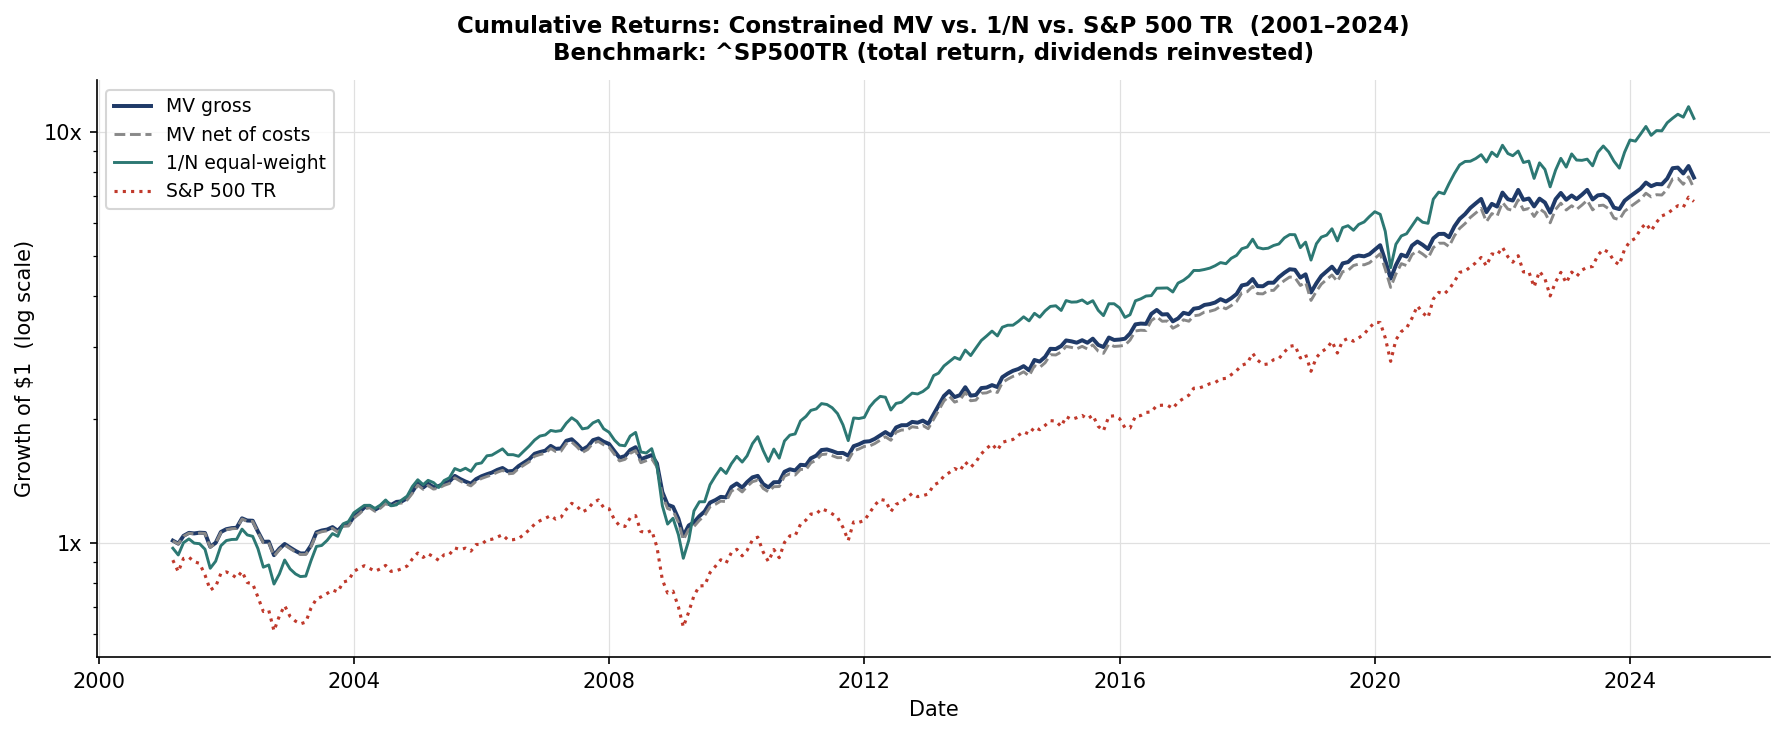

In [11]:
cum = {
    "MV gross":         (1 + r_gross).cumprod(),
    "MV net of costs":  (1 + r_net).cumprod(),
    "1/N equal-weight": (1 + r_naive).cumprod(),
    "S&P 500 TR":       (1 + r_bm).cumprod(),
}
colors     = [_NAVY, _GREY, _TEAL, _RED]
linestyles = ["-", "--", "-", ":"]
linewidths = [1.9, 1.4, 1.4, 1.5]

fig, ax = plt.subplots(figsize=(12, 5))
for (label, series), c, ls, lw in zip(cum.items(), colors, linestyles, linewidths):
    ax.plot(series.index, series.values,
            color=c, linestyle=ls, linewidth=lw, label=label)

ax.set_yscale("log")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: f"{y:.0f}x"))
ax.set_xlabel("Date", fontsize=10)
ax.set_ylabel("Growth of $1  (log scale)", fontsize=10)
ax.set_title(
    "Cumulative Returns: Constrained MV vs. 1/N vs. S&P 500 TR  (2001–2024)\n"
    "Benchmark: ^SP500TR (total return, dividends reinvested)",
    fontsize=11, fontweight="bold", pad=10,
)
ax.legend(fontsize=9, framealpha=0.8, loc="upper left")
fig.tight_layout()
plt.show()


In [12]:
def total_ret(r): return float((1 + r).prod() - 1)
def ann_ret(r):
    return float((1 + total_ret(r)) ** (12 / len(r)) - 1)

n_obs = len(r_gross)
strategies = [
    ("Constrained MV — gross", r_gross),
    ("Constrained MV — net",   r_net),
    ("1/N equal-weight",       r_naive),
    ("S&P 500 TR (passive)",   r_bm),
]

print(f"Return summary  ({r_gross.index[0].date()} to {r_gross.index[-1].date()},"
      f"  n = {n_obs} monthly observations)")
print()
header = f"  {'Strategy':<28}  {'Total':>10}  {'Annualised':>12}"
print(header)
print("  " + "-" * (len(header) - 2))
for label, r in strategies:
    print(f"  {label:<28}  {total_ret(r):>+9.1%}  {ann_ret(r):>+11.2%}")
print()
cost_drag_total = total_ret(r_gross) - total_ret(r_net)
cost_drag_ann   = ann_ret(r_gross)   - ann_ret(r_net)
mv_over_bm_ann  = ann_ret(r_gross)   - ann_ret(r_bm)
print(f"  Cost drag (gross vs net)     : {cost_drag_total:+.1%} total / {cost_drag_ann:+.2%} p.a.")
print(f"  MV gross vs S&P 500 TR       : {mv_over_bm_ann:+.2%} p.a.  (raw return premium)")


Return summary  (2001-02-28 to 2024-12-31,  n = 287 monthly observations)

  Strategy                           Total    Annualised
  ------------------------------------------------------
  Constrained MV — gross          +676.0%       +8.95%
  Constrained MV — net            +630.3%       +8.67%
  1/N equal-weight                +981.0%      +10.47%
  S&P 500 TR (passive)            +578.7%       +8.34%

  Cost drag (gross vs net)     : +45.8% total / +0.28% p.a.
  MV gross vs S&P 500 TR       : +0.61% p.a.  (raw return premium)


Several observations follow from the corrected total-return comparison.

**MV gross vs. corrected benchmark:** The constrained MV portfolio returns
+676.0% gross (+8.95% p.a.) against +578.7% for the `^SP500TR` benchmark
(+8.34% p.a.) — a raw return premium of approximately +61 basis points per
year before costs, and +33 basis points after costs.  This is economically
meaningful but far more modest than the +332 percentage-point gap produced by
the earlier (incorrect) price-only benchmark.

**The cost drag is small:** Transaction costs subtract only 28 basis points per
year from the gross return, leaving MV net well above the corrected benchmark
in cumulative terms despite high nominal two-way turnover.

**The 1/N result and the survivor-bias caveat:** Equal-weighting returns +981.0%
(+10.47% p.a.), substantially exceeding the benchmark and MV gross alike.  This
large gap is consistent with — and partly explained by — the survivorship bias in
the active universe: the 2001–2014 subsample, where coverage averages only 62.6%,
accounts for the bulk of the apparent outperformance.  In the 2015–2024 subsample
(mean coverage 86.9%), 1/N trails the S&P 500 TR by approximately 200 basis
points per year (+11.07% vs. +13.10% p.a.), confirming that the full-period
excess attributed to 1/N is a coverage artefact rather than a genuine edge,
confirming that the raw return excess is a data-quality artefact rather than a
genuine active-management signal.

**Raw returns are not the primary test.** H1 concerns *risk-adjusted*
performance. Minimum-variance strategies are designed to reduce portfolio
variance, not to maximise raw returns.  The Sharpe ratio comparison — which
accounts for the lower volatility inherent to the minimum-variance construction
— is conducted in the results notebook and constitutes the definitive test of H1.


---
## 8. Summary and What Comes Next


This notebook has established the four artefacts-free return series that all
downstream analysis consumes:

| Series | Notes |
|---|---|
| `mv_gross` | Constrained min-variance, total return before costs |
| `mv_net` | Same, after 20 bps round-trip transaction costs |
| `naive` | 1/N equal-weight over the same filtered universe |
| `benchmark` | S&P 500 Total Return (`^SP500TR`), dividends reinvested |

Key design choices documented here and carried forward throughout the thesis:

- **Point-in-time universe** (§2): avoids survivorship bias at the membership
  selection step; the residual coverage shortfall (§3b) is the primary remaining
  source of bias and is quantified via the post-2015 robustness subsample.
- **Total-return benchmark** (§4): corrects a methodologically significant
  dividend-omission error that would otherwise inflate apparent active
  outperformance by roughly 230 percentage points in cumulative terms.
- **+100% return filter** (§5): a conservative, targeted cleaning step that
  removes 376 data-artefact cells (0.19% of non-null observations) without affecting
  any legitimate return observation.
- **Ledoit-Wolf + 5% cap** (§6): a principled, low-parameter variance estimator
  paired with a realistic institutional weight constraint.

**Subsequent notebooks:**

- **`03_results.ipynb`** — the full empirical analysis: regime classification
  using the peak-to-trough drawdown rule (threshold −20%, applied to
  `^SP500TR`, via `src.regimes`), descriptive performance metrics
  (`src.metrics`), the Jobson-Korkie-Memmel Sharpe ratio test and factor
  regressions for H1 (`src.stats`), and the regime-conditional block
  bootstrap for H2 (`src.regime_analysis`).

All downstream notebooks load from the same cached `.parquet` files in
`data/processed/` and are reproducible without re-running the data pull or
the backtest.
